# Определение стоимости автомобилей

Сервис по продаже автомобилей с пробегом «Не бит, не крашен» разрабатывает приложение для привлечения новых клиентов. В нём можно быстро узнать рыночную стоимость своего автомобиля. В нашем распоряжении исторические данные: технические характеристики, комплектации и цены автомобилей. Нужно построить модель для определения стоимости. 

Заказчику важны:

- качество предсказания;
- скорость предсказания;
- время обучения.

ЦЕЛЬ:

Построить модель для определения рыночной стоимости автомобиля с пробегом.
Критерий качества модели: RMSE < 2500

ОПИСАНИЕ ДАННЫХ:

Признаки:
- `DateCrawled` — дата скачивания анкеты из базы
- `VehicleType` — тип автомобильного кузова
- `RegistrationYear` — год регистрации автомобиля
- `Gearbox` — тип коробки передач
- `Power` — мощность (л. с.)
- `Model` — модель автомобиля
- `Kilometer` — пробег (км)
- `RegistrationMonth` — месяц регистрации автомобиля
- `FuelType` — тип топлива
- `Brand` — марка автомобиля
- `Repaired` — была машина в ремонте или нет
- `DateCreated` — дата создания анкеты
- `NumberOfPictures` — количество фотографий автомобиля
- `PostalCode` — почтовый индекс владельца анкеты (пользователя)
- `LastSeen` — дата последней активности пользователя
Целевой признак:
- `Price` — цена (евро)

ДАННЫЕ:

autos.csv 

ПЛАН РАБОТ:

Последовательно пройдем все этапы:

1. Загрузим данные, изучим общую информацию, посмотрим гистограммы
2. Предобработаем данные: проверим признаки, типы данных, обработаем пропуски и дубликаты 
3. Проведем исследовательский анализ: посмотрим на описательнеые статисти и графики каждого признака, проверим на аномалии и построим матрицы корреляции
4. Подготовим выборки для обучения моделей
5. Обучим разные модели, одна из которых — LightGBM, как минимум одна — не бустинг. Для каждой модели попробуем разные гиперпараметры
6. Проанализируем время обучения, время предсказания и качество моделей
7. Опираясь на критерии заказчика, выберем лучшую модель, проверим её качество на тестовой выборке

*ИМПОРТЫ*

In [1]:
!pip install scikit-learn==1.1.3 -q
!pip install phik -q
!pip install lightgbm -q
#!pip install shap==0.46.0 -q

In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats as st

In [3]:
# преобразование данных
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    OneHotEncoder, 
    OrdinalEncoder, 
    StandardScaler, 
    MinMaxScaler
)
from sklearn.impute import SimpleImputer
# модели
from sklearn.linear_model import (
    LinearRegression, 
)
from sklearn.tree import (
    DecisionTreeRegressor, 
    plot_tree
)
from lightgbm import LGBMRegressor

# метрики
from sklearn.metrics import (
    mean_squared_error
)
# пайплайн
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
# автоподбор гиперпараметров
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV
)
import time
import phik
#import shap

*КОНСТАНТЫ*

In [4]:
RANDOM_STATE = 42

*ПОЛЬЗОВАТЕЛЬСКИЕ ФУНКЦИИ*

In [5]:
def camel_to_snake(camel_case):
    '''
    Переводит верблюжий регистр в змеиный
            Параметры:
                    camel_case: принимает верблюжий текст 
            Возвращаемое значение:
                    plt.show(): змеиный текст
    '''
    snake_case = ''
    for char in camel_case:
        if char.isupper():
            snake_case += '_' + char.lower()
        else:
            snake_case += char
    return snake_case.lstrip('_')


In [6]:
def hist_box_num_feature (df, y_text):
    '''
    Возвращает гистограмму и boxplot колличественного признака.
            Параметры:
                    df: входящий датасет 
                    y_text: наименование значения по y
            Возвращаемое значение:
                    plt.show(): вывод гистограммы и ящика с усами
    '''
    for feature in con:
        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,3))
        df[feature].plot(kind='hist', bins=10, ax=axes[0])
        axes[0].set_title(f'Признак: {feature} \n Гистограмма распределения')
        axes[0].set_ylabel(f'Количество {y_text}')
        axes[0].set_xlabel(f'{feature}')
        df[feature].plot(kind='box', ax=axes[1])
        axes[1].set_title(f'Признак: {feature} \n Разброс значений')
        plt.ylabel("Значение признака")
        plt.grid(True)
        plt.show()

In [7]:
def barh_feature_name (df, feature, y_text):
    '''
    Возвращает столбчатую диаграмму дискретного 
                   или категориального признака
            Параметры:
                    df: входящий датасет
                    feature: признак
                    y_text: наименование значения по y
            Возвращаемое значение:
                    plt.show(): вывод столбчатой диаграммы
    '''
    ax = df[feature].value_counts(ascending=True).plot.barh(figsize=(8,3))
    plt.xlabel(f'Количество {y_text}')
    plt.grid(True)
    plt.title(f'Распределение признака: {feature}')
    return plt.show()

## Подготовка данных

### Загрузка данных

#### Считаем файлы с данными и загрузим их в соответствующий датафрейм

In [8]:
try:
    autos = pd.read_csv('autos.csv')
except:
    autos = pd.read_csv(
        'https://code.s3.yandex.net/datasets/autos.csv')

#### Выведем частично датафрейм и изучим общую информацию

In [9]:
autos.head()

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


In [10]:
autos.tail()

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
354364,2016-03-21 09:50:58,0,NaN,2005,manual,0,colt,150000,7,petrol,mitsubishi,yes,2016-03-21 00:00:00,0,2694,2016-03-21 10:42:49
354365,2016-03-14 17:48:27,2200,NaN,2005,NaN,0,NaN,20000,1,NaN,sonstige_autos,NaN,2016-03-14 00:00:00,0,39576,2016-04-06 00:46:52
354366,2016-03-05 19:56:21,1199,convertible,2000,auto,101,fortwo,125000,3,petrol,smart,no,2016-03-05 00:00:00,0,26135,2016-03-11 18:17:12
354367,2016-03-19 18:57:12,9200,bus,1996,manual,102,transporter,150000,3,gasoline,volkswagen,no,2016-03-19 00:00:00,0,87439,2016-04-07 07:15:26
354368,2016-03-20 19:41:08,3400,wagon,2002,manual,100,golf,150000,6,gasoline,volkswagen,NaN,2016-03-20 00:00:00,0,40764,2016-03-24 12:45:21


In [11]:
autos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Kilometer          354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  Repaired           283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

#### Ознакомимся с гистограммами числовых признаков. Подробно изучим их во время исследовательского анализа

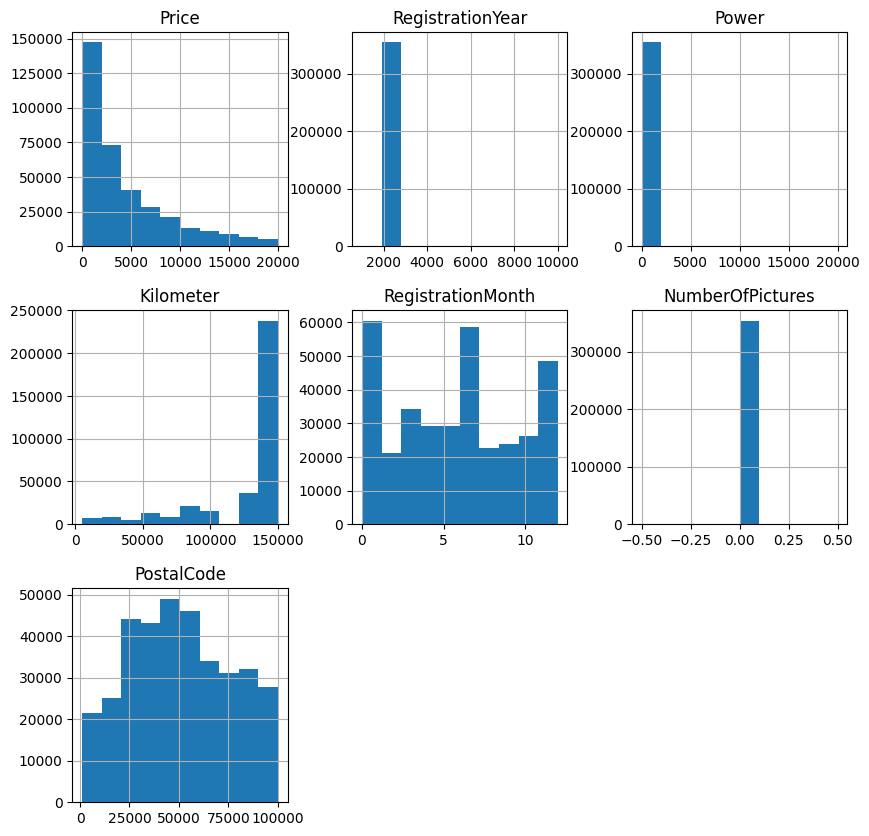

In [12]:
autos.hist(figsize=(10, 10))
plt.show()

*ВЫВОД: 
1. Разное количество значений Non-Null в признаках говорит о пропусках
2. Признаки можно разделить на 2 группы:  - влияют на определение рыночной цены и - не влияют. 
Не информативные признаки удалим: 
`DateCrawled`, `DateCreated`, `NumberOfPictures`, `PostalCode`, `LastSeen`
3. `Power` — мощность (л. с.) судя по гистограмме с аномалиями
4. `RegistrationMonth` — месяц регистрации автомобиля имеет смысл рассматривать совместно с годом регистрации, год, вероятно, имеет аномалии
5. `Price` - непрерывный
6. `Kilometer` — пробег (км) теоретически должен быть непрерывным, однако есть вероятность того, что при заполнениии анкеты происходит очень грубое округление и признак мог стать дискретным. Надо смотреть детальнее*

### Предобработка данных

#### Удалим неинформативные признаки

In [13]:
autos = autos.drop(['DateCrawled','DateCreated', 'NumberOfPictures', 'PostalCode', 'LastSeen'], axis=1)

#### Приведем названия признаков к привычному "змеиному регистру" 

In [14]:
for col in autos.columns.tolist():
    col_new = camel_to_snake(col)
    autos = autos.rename(columns={col: col_new})

In [15]:
autos.head()

,price,vehicle_type,registration_year,gearbox,power,model,kilometer,registration_month,fuel_type,brand,repaired
0,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN
1,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes
2,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN
3,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no
4,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no


#### Посмотрим пропуски

In [16]:
autos.isna().sum()

price                     0
vehicle_type          37490
registration_year         0
gearbox               19833
power                     0
model                 19705
kilometer                 0
registration_month        0
fuel_type             32895
brand                     0
repaired              71154
dtype: int64

*Посмотрим на процентное соотношение*

In [17]:
100*autos.isna().mean()

price                  0.000000
vehicle_type          10.579368
registration_year      0.000000
gearbox                5.596709
power                  0.000000
model                  5.560588
kilometer              0.000000
registration_month     0.000000
fuel_type              9.282697
brand                  0.000000
repaired              20.079070
dtype: float64

*Возможно пропуски связаны. В нашем случае если одновременно стоит пропуск и в типе ТС и в модели, то такая строка становится неинформативной*

In [18]:
autos[autos['vehicle_type'].isna() & autos['model'].isna()]

,price,vehicle_type,registration_year,gearbox,power,model,kilometer,registration_month,fuel_type,brand,repaired
260,450,NaN,2016,manual,0,NaN,150000,3,petrol,mitsubishi,no
306,200,NaN,2009,NaN,0,NaN,10000,0,NaN,sonstige_autos,NaN
435,1300,NaN,2017,manual,150,NaN,150000,10,NaN,volkswagen,no
443,1950,NaN,2017,manual,0,NaN,150000,7,petrol,volkswagen,no
478,0,NaN,2000,manual,0,NaN,150000,0,NaN,audi,yes
...,...,...,...,...,...,...,...,...,...,...,...
354083,0,NaN,2000,NaN,0,NaN,150000,0,NaN,sonstige_autos,NaN
354162,1500,NaN,1995,NaN,0,NaN,150000,0,NaN,volkswagen,NaN
354338,180,NaN,1995,NaN,0,NaN,125000,3,petrol,opel,NaN
354351,1900,NaN,2000,manual,110,NaN,150000,7,NaN,volkswagen,no


*Удаляем*

In [19]:
autos = autos.dropna(how='all', subset=['vehicle_type', 'model'])

In [20]:
100*autos.isna().mean()

price                  0.000000
vehicle_type           8.822556
registration_year      0.000000
gearbox                4.840004
power                  0.000000
model                  3.705174
kilometer              0.000000
registration_month     0.000000
fuel_type              8.223778
brand                  0.000000
repaired              19.185650
dtype: float64

In [21]:
autos.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 347541 entries, 0 to 354368
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   price               347541 non-null  int64 
 1   vehicle_type        316879 non-null  object
 2   registration_year   347541 non-null  int64 
 3   gearbox             330720 non-null  object
 4   power               347541 non-null  int64 
 5   model               334664 non-null  object
 6   kilometer           347541 non-null  int64 
 7   registration_month  347541 non-null  int64 
 8   fuel_type           318960 non-null  object
 9   brand               347541 non-null  object
 10  repaired            280863 non-null  object
dtypes: int64(5), object(6)
memory usage: 31.8+ MB


*Все пропуски в категориальных признаках. Самое большое количество в признаке `repaired` (была ли машина в ремонте). Важнейший признак с точки зрения обывательской логики. Его никак не заполнить чем-нибудь "подходящим", поэтому заполним его `other`. Аналогично поступим и с остальными признаками*

*Пропуски обработаем в пайплайне. Таким образом мы избежим возможных ошибок в будущем при поступлении новых данных с возможными пропусками. Заполняем `other` так как это значение уже встречается в признаках, и чтобы не плодить неизвестность, пусть все будут other* 

#### Проверим уникальные значения категориальных признаков

In [22]:
for feature in autos.select_dtypes(include='object').columns.tolist():
    print(autos[feature].unique())

[nan 'coupe' 'suv' 'small' 'sedan' 'convertible' 'bus' 'wagon' 'other']
['manual' 'auto' nan]
['golf' nan 'grand' 'fabia' '3er' '2_reihe' 'other' 'c_max' '3_reihe'
 'passat' 'navara' 'ka' 'polo' 'twingo' 'a_klasse' 'scirocco' '5er'
 'meriva' 'arosa' 'c4' 'civic' 'transporter' 'punto' 'e_klasse' 'clio'
 'kadett' 'kangoo' 'corsa' 'one' 'fortwo' '1er' 'b_klasse' 'signum'
 'astra' 'a8' 'jetta' 'fiesta' 'c_klasse' 'micra' 'vito' 'sprinter' '156'
 'escort' 'forester' 'xc_reihe' 'scenic' 'a4' 'a1' 'insignia' 'combo'
 'focus' 'tt' 'a6' 'jazz' 'omega' 'slk' '7er' '80' '147' '100' 'z_reihe'
 'sportage' 'sorento' 'v40' 'ibiza' 'mustang' 'eos' 'touran' 'getz' 'a3'
 'almera' 'megane' 'lupo' 'r19' 'zafira' 'caddy' 'mondeo' 'cordoba' 'colt'
 'impreza' 'vectra' 'berlingo' 'tiguan' 'i_reihe' 'espace' 'sharan'
 '6_reihe' 'panda' 'up' 'seicento' 'ceed' '5_reihe' 'yeti' 'octavia' 'mii'
 'rx_reihe' '6er' 'modus' 'fox' 'matiz' 'beetle' 'c1' 'rio' 'touareg'
 'logan' 'spider' 'cuore' 's_max' 'a2' 'galaxy' 'c3

*переименуем gasoline в petrol, поскольку оба означают "бензин"*

In [23]:
autos['fuel_type'] = autos['fuel_type'].replace(['gasoline'],'petrol')

*Тип пропусков один - nan. Было бы здорово отправить список названий моделей автопрофессионалу на предмет проверки опечаток в написании, но в данном случае сделаем допущение, что при заполнении анкеты происходит выбор из выпадающего списка, что исключает опечатки. На эту мысль наводит и значение `other`, встречающееся в уникальных значениях признаков*

#### Посмотрим дубликаты

In [24]:
autos.duplicated().sum()

27006

In [25]:
100*autos.duplicated().sum()/autos.shape[0]

7.77059397308519

*Довольно много, почти 8%. Наличие признака однозначно идентифицирующего машину, дало бы понимание дубли это или совпадения, но... Будем удалять. Если бы перед нами стояла задача класификации, то с дублями нужно было бы поработать плотнее. При удалении есть риск нарушить соотношение классов. Но у нас задача регрессии, поэтому удаление наиболее логичное решение*

In [26]:
autos = autos.drop_duplicates()

In [27]:
autos.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 320535 entries, 0 to 354368
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   price               320535 non-null  int64 
 1   vehicle_type        291445 non-null  object
 2   registration_year   320535 non-null  int64 
 3   gearbox             305404 non-null  object
 4   power               320535 non-null  int64 
 5   model               308148 non-null  object
 6   kilometer           320535 non-null  int64 
 7   registration_month  320535 non-null  int64 
 8   fuel_type           293129 non-null  object
 9   brand               320535 non-null  object
 10  repaired            257996 non-null  object
dtypes: int64(5), object(6)
memory usage: 29.3+ MB


*ВЫВОД: Удалили неинформативные признаки и дубликаты. Один тип пропусков (NAN). Необходимо предусмотреть заполнение пропусков и обработку неизвестных категорий. Сделаем это в пайплайне. На аномалии посмотрим в исследовательском анализе*

### Исследовательский анализ данных

#### Посмотрим описательные статистики количественных признаков

In [28]:
autos.describe()

,price,registration_year,power,kilometer,registration_month
count,320535.000000,320535.000000,320535.000000,320535.000000,320535.000000
mean,4447.335898,2003.712874,111.206648,128333.239740,5.746231
std,4529.220054,70.367873,196.663202,37588.709885,3.703277
min,0.000000,1000.000000,0.000000,5000.000000,0.000000
25%,1100.000000,1999.000000,69.000000,125000.000000,3.000000
50%,2750.000000,2003.000000,105.000000,150000.000000,6.000000
75%,6480.000000,2007.000000,143.000000,150000.000000,9.000000
max,20000.000000,9999.000000,20000.000000,150000.000000,12.000000


*Во всех признаках, кроме пробега, очевидны аномалии. Посмотрим на уникальные значения*

In [29]:
for feature in autos.select_dtypes(include='int64').columns.tolist():
    print(autos[feature].unique())

[  480 18300  9800 ... 12395 18429 10985]
[1993 2011 2004 2001 2008 1995 1980 2014 1998 2005 1910 2016 2007 2009
 2002 2018 1997 1990 2017 1981 2003 1994 1991 1984 2006 1999 2012 2010
 2000 1992 2013 1996 1985 1989 2015 1982 1976 1983 1973 1969 1971 1987
 1986 1988 1965 1970 1945 1925 1974 1979 1955 1978 1972 1968 1977 1961
 1960 1966 1975 1963 1964 5000 1954 1958 1967 1959 1956 1000 1941 9999
 1500 2200 1962 1929 1957 1940 3000 2066 1949 2019 1937 1951 1953 8000
 9000 2900 5900 5911 1933 1400 1950 4000 1948 1952 1200 8500 1932 3700
 1942 1935 1234 1936 6500 1923 2290 1930 1001 1944 7000 1943 1934 1938
 1928 1800 1919 5555 6000 1300 1931 1915 4500 1920 1602 1111 7800 1947
 1927 7100 2500 8200 1946 7500 1600]
[    0   190   163    75    69   102   109    50   125   101   105   140
   115   131    60   136   160   231    90   118   193    99   113   218
   122   129    70   306    95    61   177    80   170    55   143    64
   286   232   150   156    82   155    54   185    87   180   

*Все признаки, кроме пробега и месяца, можно считать непрерывными. Аномалий много* 

#### Построим гистограммы и ящик с усами для нерерывных признаков и столбчатую диаграмму для дискретных

In [30]:
con = autos.select_dtypes(include=['int64']).columns.tolist()[:3]
dis = autos.select_dtypes(include=['int64']).columns.tolist()[3:]

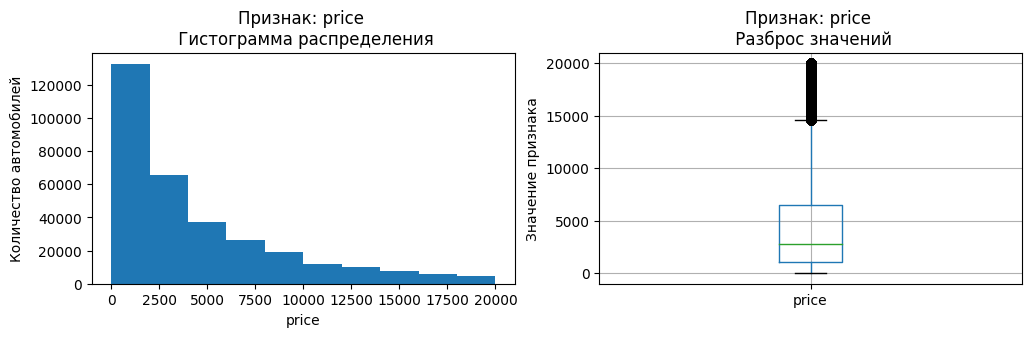

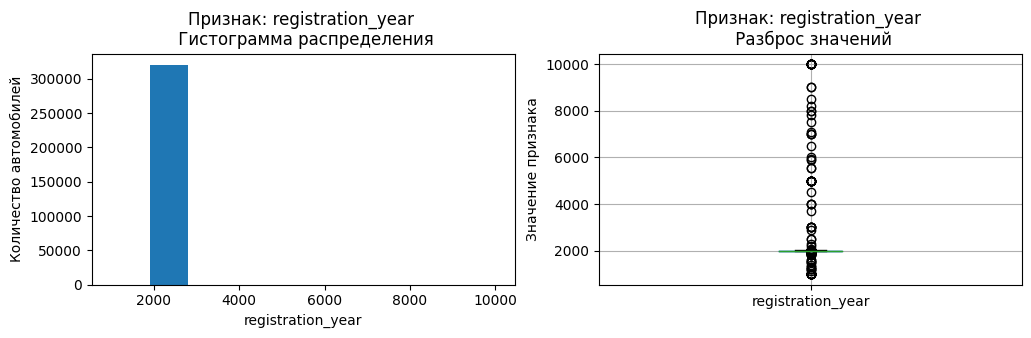

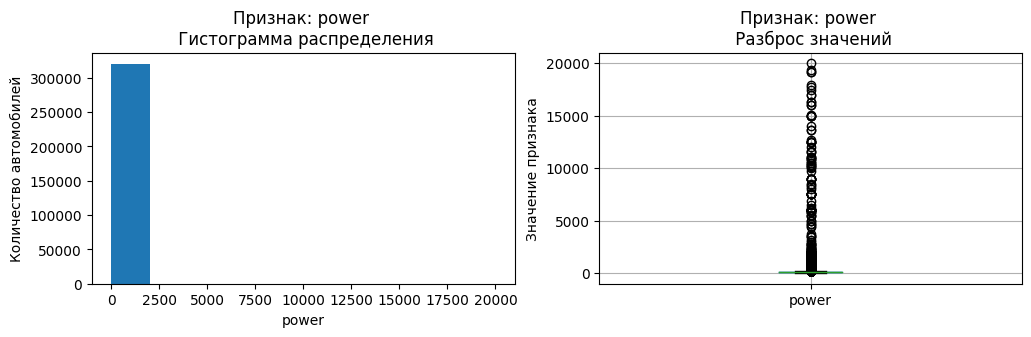

In [31]:
hist_box_num_feature(autos, 'автомобилей')

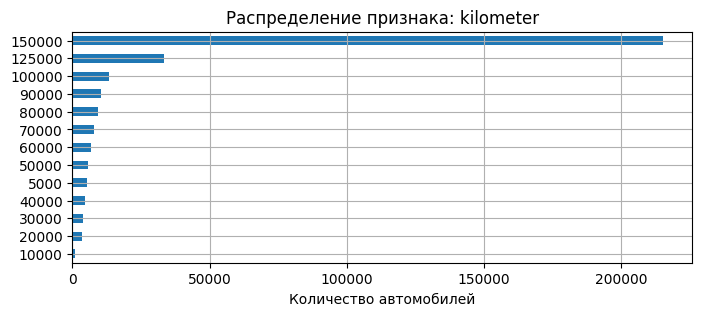

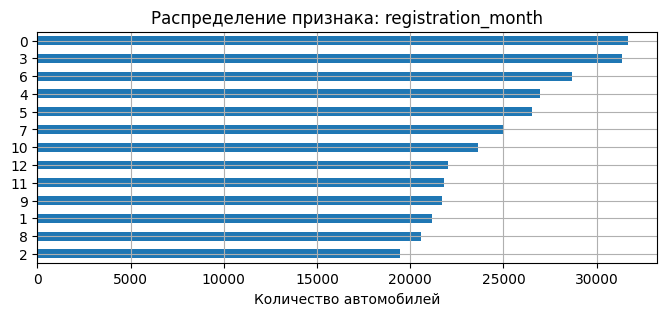

In [32]:
for feature in dis:
    barh_feature_name(autos, feature, 'автомобилей')

*По дискретным:
  1. Пробег выглядит вполне реалистичным, подавляющее большинство с пробегом более 200 тыс
  2. Месяц итак не очень-то информативен сам по себе. Он актуален для машин не старше 3-х лет. Чем старше машина, тем меньше внимания обращается на месяц регистрации. Как отдельный признак для обучения его вообще странно рассматривать. Так еще и аномальных нулей у него больше всего значений. Удалим месяц из признаков* 

In [33]:
autos = autos.drop('registration_month', axis=1)

*Теперь разбиремся с аномалиями непрерывных, начнем с года. На боксплоте сплошная аномалия. Отсечем явные косяки. Первый автомобиль вышел в 1886, и хотя он был трехколесный и врядли продается на нашем сервисе. Но на нашем сервисе продаются ретроавтомобили 1910, 1915 и т. д. Нашей моделью сложно будет предсказать стоимость ретроавто, у них другой принцып ценообразования. Отсечем ретро, порекомендуем заказчику для этого сегмента построить другую модель. Посмотрим, где установить нижнюю границу*

*Интересно, в данных встречаются как возможно разумные записи, например, bmv купе 1923 12 л.с., так и весьма странные, такие как volkswagen неизвестной модели с мощностью 600 л.с. 1910г. Поэтому отсечение ретро годов поможет нам и с удалением аномалий*

In [34]:
autos[autos['registration_year'] < 1980].shape[0]

3140

*Подойдет. Нижняя граница 1980, верхняя - дата выгрузки данных 2016*

*Избавляемся*

In [35]:
autos = autos[(autos['registration_year'] < 2016) & (autos['registration_year'] > 1980)]
autos['registration_year'].describe()

count    297070.000000
mean       2002.450362
std           5.667006
min        1981.000000
25%        1999.000000
50%        2003.000000
75%        2007.000000
max        2015.000000
Name: registration_year, dtype: float64

*Теперь по мощности двигателя. Есть даже 5 значные значения. Возможно, съехала запятая, и вместо 10912 должно быть 109,12. Однако, для 3-х и 4-х значных мы не можем с уверенностью сказать на сколько знаков сместить запятую. Напимер: *

In [36]:
autos[autos['power'] == 685]

,price,vehicle_type,registration_year,gearbox,power,model,kilometer,fuel_type,brand,repaired
158216,5000,other,2010,manual,685,kangoo,150000,petrol,renault,NaN


*На данный момент какие-нибудь спорткары или электромобили имеют заявленную мощность 2000 и более... В данном примере 685 вполне реальная мощность, но если мы посмотрим на эту конкретную модель, то ее заявленная мощность 68,5 л. с. Поэтому лучше удалить непроверенные данные, чем вводить модель в заблуждение. Тем более, что некоторые модели очень чуствительны к выбросам*

*Посмотрим, что нам говорит ИИ... Подавляющее большинство серийных современных автомобилей располагается в пределах 90-300 л.с*

In [37]:
autos[autos['power'] > 600].shape[0]

315

In [38]:
100*autos[autos['power'] > 600].shape[0]/autos.shape[0]

0.10603561450163261

*Удалим без сожалений. Даже если под удаление попали реальные значения, а не аномалии, то их 1-цы. Вероятно заказчик захочет видеть модель которая, более точно предсказывает основную часть запросов и довольно сильно ошибается в редких "выдающихся" случаях, чем модель, которая так себе работает на всем диапазоне*

*Нулевая мощность тоже вызывает сильные подозрения*

In [39]:
autos[autos['power'] == 0].shape[0]

27630

In [40]:
100*autos[autos['power'] == 0].shape[0]/autos.shape[0]

9.300838186286061

*Так как мы отсекли сегмент ретроавто, то для автомобилей старше 1980 самая маленькая возможная мощность 20 л. с., характерная для малолитражек того времени. Все, что меньше - не корректно*

In [41]:
autos[autos['power'] < 20].shape[0]

27897

In [42]:
100*autos[autos['power'] < 50].shape[0]/autos.shape[0]

10.85165112599724

In [43]:
autos = autos[(autos['power'] < 600) & (autos['power'] > 20)]
autos['power'].describe()

count    268839.000000
mean        121.142040
std          53.666603
min          21.000000
25%          79.000000
50%         113.000000
75%         150.000000
max         599.000000
Name: power, dtype: float64

*Целевой `price` на удивление тоже имеет нулевые значения*

In [44]:
autos[autos['price'] == 0].shape[0]

5137

In [45]:
100*autos[autos['price'] == 0].shape[0]/autos.shape[0]

1.9108090716004746

In [46]:
autos[autos['price'] == 0].head(10)

,price,vehicle_type,registration_year,gearbox,power,model,kilometer,fuel_type,brand,repaired
152,0,bus,2004,manual,101,meriva,150000,lpg,opel,yes
231,0,wagon,2001,manual,115,mondeo,150000,NaN,ford,NaN
563,0,sedan,1998,auto,230,NaN,150000,petrol,saab,NaN
579,0,sedan,1996,manual,170,5er,150000,petrol,bmw,no
615,0,sedan,1998,manual,75,polo,150000,petrol,volkswagen,yes
730,0,small,2005,manual,75,2_reihe,150000,petrol,peugeot,NaN
859,0,wagon,2009,manual,170,a6,150000,petrol,audi,yes
986,0,small,1995,manual,90,NaN,125000,petrol,volkswagen,no
1002,0,small,1997,manual,75,NaN,150000,petrol,peugeot,NaN
1032,0,small,2003,auto,170,stilo,150000,petrol,fiat,no


*Ну дела... А есть ли аномально низкие кроме 0?*

In [47]:
100*autos[autos['price'] < 50].shape[0]/autos.shape[0]

2.1466379505949655

*И хочется удалить и колется. А вдруг эти заявки реальные нулевые, ну например машина после аварии восстановлению не подлежит и хоть бы кто-нибудь забрал на запчасти, или за 1 евро, как котят отдают. Что бы за стоянку не платить. Или как в начале 10-тых автоваз предлагал 50 000 за разбитую развалюху в счет новой гранты, например... Все-таки удалим неадекватные значения < 50 евро*

In [48]:
autos = autos[autos['price'] > 50]

*Посмотрим еще разок на статистики, гистограмки и боксплоты*

In [49]:
autos.describe()

,price,registration_year,power,kilometer
count,262933.000000,262933.000000,262933.000000,262933.000000
mean,4883.370246,2002.762015,121.203314,128481.533318
std,4614.023865,5.626374,53.569579,36448.223903
min,55.000000,1981.000000,21.000000,5000.000000
25%,1350.000000,1999.000000,80.000000,125000.000000
50%,3200.000000,2003.000000,113.000000,150000.000000
75%,6999.000000,2007.000000,150.000000,150000.000000
max,20000.000000,2015.000000,585.000000,150000.000000


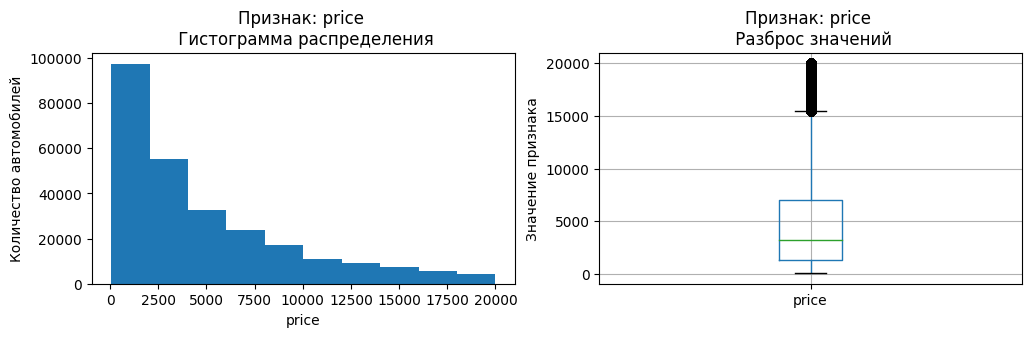

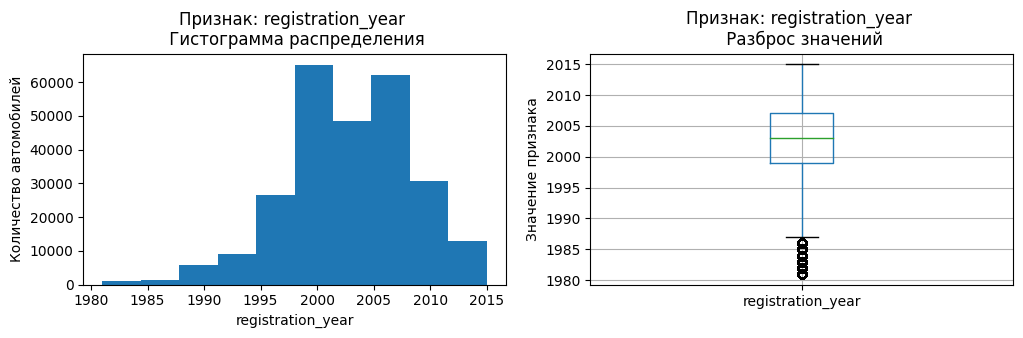

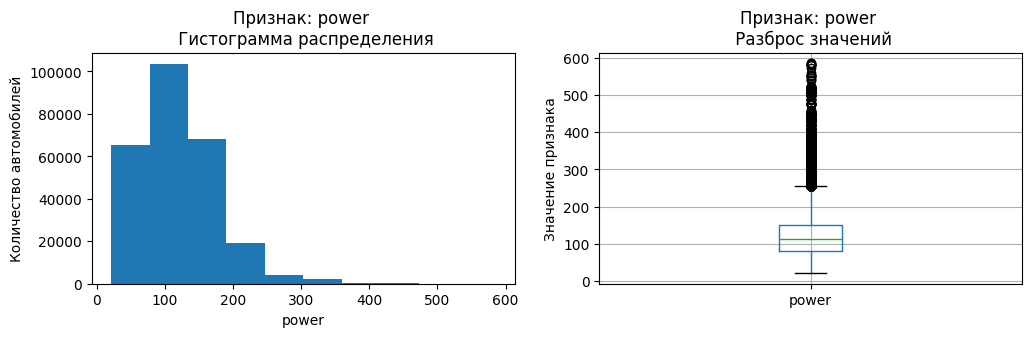

In [50]:
hist_box_num_feature(autos, 'автомобилей')

#### Для категориальных признаков построим столбчатые диаграммы

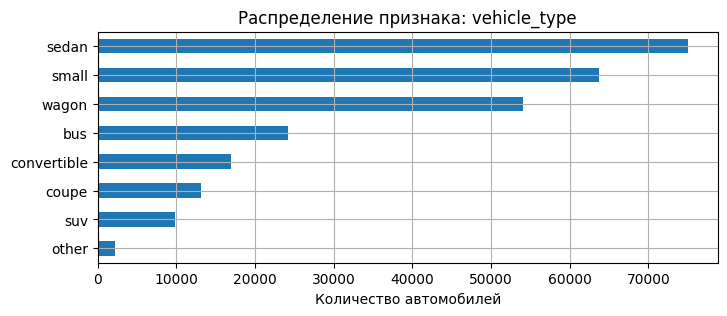

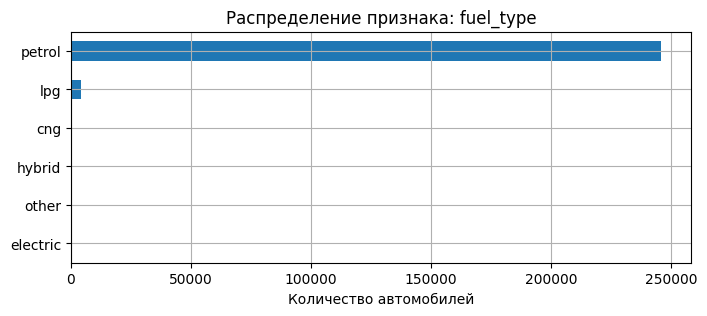

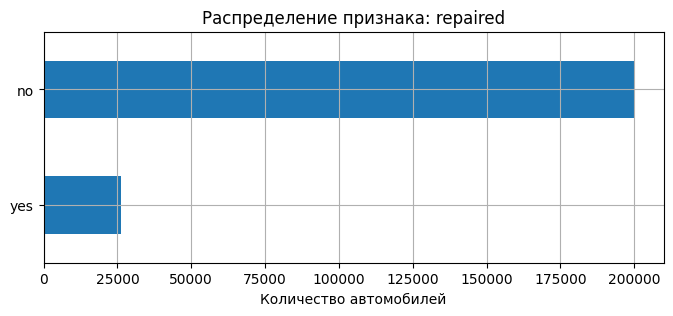

In [51]:
for feature in ['vehicle_type', 'fuel_type', 'repaired']:
    barh_feature_name(autos, feature, 'автомобилей')

*Для `brand` построим отдельным кодом с другими размерами графика*

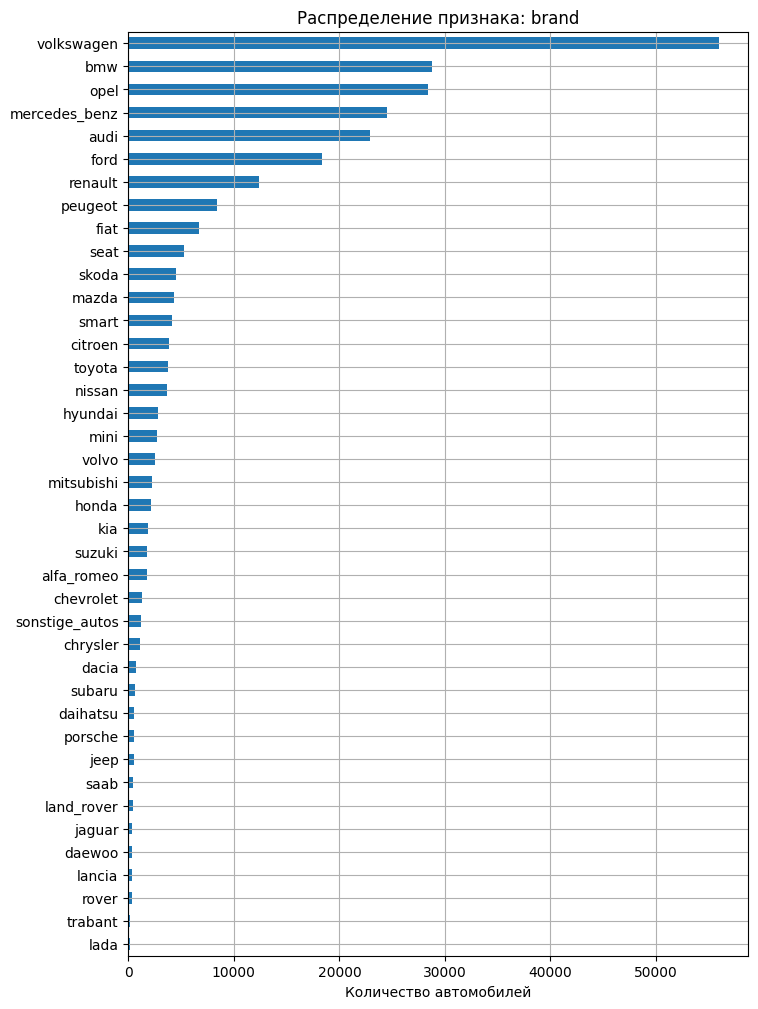

In [52]:
ax = autos['brand'].value_counts(ascending=True).plot.barh(figsize=(8,12))
plt.xlabel('Количество автомобилей')
plt.grid(True)
plt.title('Распределение признака: brand')
plt.show()

*А для `model` не будем строить частокол из 250 столбиков, а просто посмотрим на числовое распределение* 

In [53]:
autos['model'].value_counts()

golf                  21561
other                 17957
3er                   15602
polo                   9374
corsa                  8764
                      ...  
i3                        5
kalina                    4
rangerover                2
serie_2                   1
range_rover_evoque        1
Name: model, Length: 248, dtype: int64

*Ну, собственно, ничего неожиданного по категориальным мы не получили... Думаю, если бы данные включали бы информацию последних лет, то лада бы поднялась повыше и китайцы были бы заявлены активнее. Странно, что в 'model' `other` занимает второе место... Возможно, там как раз сидят все китайцы*

*ВЫВОД: 
1. Удалили признак "месяц регистрации" в связи с малой информативностью и высокой аномальностью
2. Почистили "год регистрации" от аномалий. Отсекли сегмент ретроавто. 
3. Отсекли аномалии "мощности" заявив верхнюю границу в 600 л.с. и нижнюю в 20 так как сегмент ретро отсечен
4. Прайс. Отсекли неадекватные значения < 50 евро. Теоретически, хорошо бы проконсультироваться с клиентом - бывают ли реальные заявки с "около-нулевой" ценой и проверить реалистичность заявок с максимальной
5. Признак 'model' супермультиклассовый. 250 классов. Хмммм. Надо думать как кодировать*

#### Посмотрим на матрицу корреляции

*Так как часть признаков в нашем датасете категориальные, нам лучше подойдет коэффициент корреляции Фи. Построим матрицу корреляций. Передадим параметру interval_cols список непрерывных признаков*

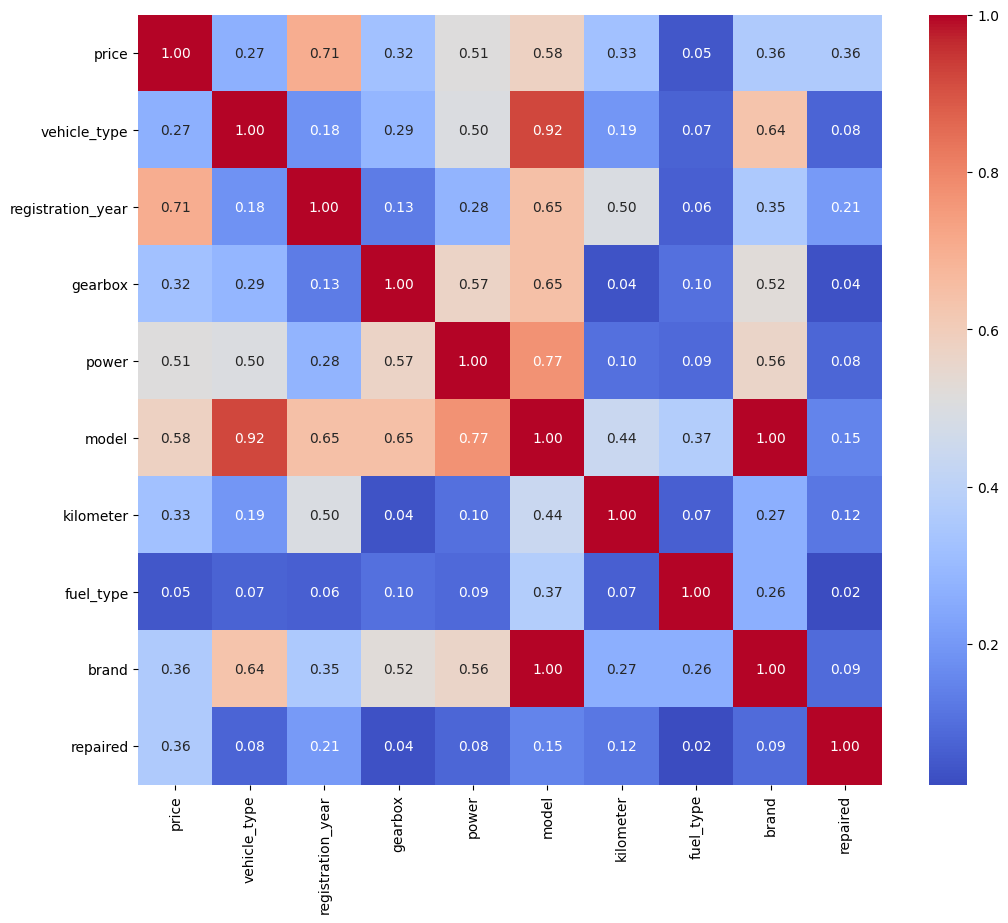

In [54]:
plt.figure(figsize = (12,10))
ax = sns.heatmap(autos.phik_matrix(
    interval_cols=con), annot=True, fmt='.2f', cmap= 'coolwarm')

*Вот это поворотец! Ну конечно следовало ожидать, что `model` будет мультиколинеарна и с `brand` и с `vehicle_type`, но не настолько же. Ведь в данных есть всякие other... Придется эти признаки удалить. Так же довольно высоки значения корреляции у `model` с `power`. Но `power` оставляем. С целевым `price` вполне себе нормально коррелирует `model`, так же в теплой зоне `registration_year` и `power`. Если удалить из признаков `vehicle_type` и `brand`, то в строках, где в признаке `model` есть пропуски вообще не останется дельной информации... Поэтому удалим только `brand`, а `vehicle_type` и `model` сконкатенируем*

*Вообще мультиколлинеарность критична для линейных моделей. Деревянные или случайный лес практически не  подвержены ее влиянию. Но все-таки мультиколлинеарность может оказывать и на них негативное влияние.*

In [55]:
autos = autos.drop(['brand'], axis=1)

*Для того что бы корректно сконкатенировать, нужно заполнить пропуски в обоих объединяемых столбцах. Мы собирались сделать это в пайплаене, но сделаем это сейчас и сзазу для всех*

In [56]:
autos = autos.fillna('other')

In [57]:
autos['model_vehicle_type'] = autos['model'] + ' ' + autos['vehicle_type']
autos = autos.drop(['model', 'vehicle_type'], axis=1)
autos.head()

,price,registration_year,gearbox,power,kilometer,fuel_type,repaired,model_vehicle_type
1,18300,2011,manual,190,125000,petrol,yes,other coupe
2,9800,2004,auto,163,125000,petrol,other,grand suv
3,1500,2001,manual,75,150000,petrol,no,golf small
4,3600,2008,manual,69,90000,petrol,no,fabia small
5,650,1995,manual,102,150000,petrol,yes,3er sedan


In [58]:
autos['model_vehicle_type'].value_counts()

golf sedan       12337
polo small        8275
corsa small       8239
3er sedan         6691
other sedan       6315
                 ...  
5_reihe small        1
q3 other             1
punto bus            1
micra wagon          1
amarok other         1
Name: model_vehicle_type, Length: 1138, dtype: int64

*После изменения признаков еще раз посмотрим на дубликаты*

In [59]:
autos.duplicated().sum()

16658

In [60]:
autos = autos.drop_duplicates()

*Посмотрим, что осталось...*

In [61]:
autos.head()

,price,registration_year,gearbox,power,kilometer,fuel_type,repaired,model_vehicle_type
1,18300,2011,manual,190,125000,petrol,yes,other coupe
2,9800,2004,auto,163,125000,petrol,other,grand suv
3,1500,2001,manual,75,150000,petrol,no,golf small
4,3600,2008,manual,69,90000,petrol,no,fabia small
5,650,1995,manual,102,150000,petrol,yes,3er sedan


In [62]:
autos.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 246275 entries, 1 to 354368
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   price               246275 non-null  int64 
 1   registration_year   246275 non-null  int64 
 2   gearbox             246275 non-null  object
 3   power               246275 non-null  int64 
 4   kilometer           246275 non-null  int64 
 5   fuel_type           246275 non-null  object
 6   repaired            246275 non-null  object
 7   model_vehicle_type  246275 non-null  object
dtypes: int64(4), object(4)
memory usage: 16.9+ MB


*ВЫВОД: При подготовке данных было удалено около 23% строк (аномальные и неинформативные и дубли), 7 признаков (неинформативные и мультиколлинеарные), 2 признака сконкатенировали*

## Обучение моделей

### Подготовка данных

*Для сравнения планирую обучить 3 модели: линейную, дерево или и LightGBM. У этих моделей разное отношение к подготовке данных (кодированию и масштабированию). Так как в нашу задачу входит минимизация времени обучения и времени предсказания, то данные будем готовить по разному, в зависимости от модели*

*Для ускорения процесса подбора лучшей модели несколько прорядим данные*

In [63]:
df=autos.sample(frac=0.05)

#### Сформируем наши выборки

In [64]:
X = df.drop(['price'], axis=1)
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)

#### Подготовим списки признаков

*Для категориальных: OneHotEncoder нам подходит лучше всего. Однако есть нюанс. У нас ecть супермультиклассовый признак `model_vehicle_type` (1138 категорий)! ОНЕ раздует нам количество признаков до невероятных размеров. OrdinalEncoder не будет раздувать признаки, но он для кодировки ранговых признаков. Если я правильно понимаю, то для линейной модели надо все-таки использовать ОНЕ так как иерархия может стать проблемой. Алгоритм может подумать, что между категориями есть логичная математическая связь, хотя в действительности её нет. А для дерева можно использовать ORD не обращая внимания на ранговость, этим мы снизим время работы модели. Для бустинга LightGBM такая же подготовка, как для дерева, потому что используется градиентный бустинг деревьев решений. А у CatBoost вообще свой кодировщик (если останется время, попробую и его). Поэтому соберем одинаковые списки и для ОНЕ и для ORD. Каждый для своей модели*

In [65]:
ohe_columns = X.select_dtypes(include=['object']).columns.tolist()

In [66]:
ord_columns = X.select_dtypes(include=['object']).columns.tolist()

*Количественные отмасштабируем скейлером. Но для линейной модели будем его использовать, а для деревянной нет. Дерево по другому принимает решения, ему по большому счету все равно отмасштабированы данные или нет*

In [67]:
num_columns = X.select_dtypes(include=['int64']).columns.tolist()

#### OHE

*Закодируем с помощью OneHotEncoder. Для устранения "дамми-ловушек" будем удалять каждый первый стлбец. В данных есть пропуски. Даже если их удалить или заполнить на этапе подготовки даных, то нет гарантий, что их не будет в данных на которых модель будет делать реальные прогнозы. Поэтому предусмотрим такой вариант с помощью SimpleImputer. Мне кажется не правильным в данном случае использовать стратегию заполнения модой, например. Кажется логичным заполнить их константой. Заполним их `other`*

In [68]:
# SimpleImputer + OHE
'''
Возможные пропуски заполняем с помощью SimpleImputer 
'''
ohe_pipe = Pipeline(
    [
        ('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, 
                                            strategy='constant', 
                                            fill_value='other')),
        ('ohe', OneHotEncoder(drop='first', 
                              handle_unknown='ignore', 
                              sparse=False))
    ]
)

#### ORD

*Для OrdinalEncoder можно не задавать порядок категоризации. По умолчанию он закодирует в алфовитном порядке. А нам все равно, ведь реально признак не ранговый. Поэтому параметр categories=categories_list не используем. Здесь я тоже выбираю стратегию заполнения константой вместо unknown_value=np.nan. И тогда на этапе кодирования неизвестные категории не будем заполнять nan, чтобы потом заполнять их константой, а сразу заполним -1. Тогда нам не нужен шаг simpleImputer_after_ord (заполнение пропусков после кодирования)*

In [69]:
# SimpleImputer + ORD 

'''
Возможные пропуски заполняем с помощью SimpleImputer
Используем порядок категоризации по умолчанию (по алфавиту)
Неизвестные категории кодируем константой -1
'''

ord_pipe = Pipeline(
    [
        ('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, 
                                                   strategy='constant', 
                                                   fill_value='other')),
        ('ord',  OrdinalEncoder(handle_unknown='use_encoded_value', 
                                unknown_value=-1))
    ]
) 

#### Выбираем скейлер для линейной модели

*Возьмем MinMaxScaler. Кажется логичным, ведь категории будут закодированы бинарно*

#### ColumnTransformer для линейной модели

In [70]:
# Пайплайн для подготовки данных для линейной модели

'''
Аргумент remainder='passthrough' позволит не применять 
шаги пайплайна к данным, которые должны остаться без изменений
'''

data_preprocessor_lr = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
)

#### ColumnTransformer для DecisionTreeRegressor и LGBMRegressor

In [71]:
# Пайплайн для подготовки данных для дерева

'''
Аргумент remainder='passthrough' позволит не применять 
шаги пайплайна к данным, которые должны остаться без изменений
'''

data_preprocessor_ord = ColumnTransformer(
    [
        ('ord', ord_pipe, ord_columns),
    ], 
    remainder='passthrough'
)

*Планируем подобрать лучшую модель с лучшими гиперпараметрами с помощью RandomizedSearchCV*

#### Соберем финальный пайплайн на базе линейной регрессии

In [72]:
pipe_final = Pipeline(
    [
        ('preprocessor', data_preprocessor_lr),
        ('models', LinearRegression())
    ]
)

#### Соберем и обучим RandomizedSearchCV для 3-х моделей и их гиперпараметров

In [73]:
param_grid = [
    
     # словарь для модели LinearRegression()
    {
        'models': [LinearRegression()],
        'preprocessor': [data_preprocessor_lr],
        'models__fit_intercept': [True, False]
    },  
    # словарь для модели DecisionTreeRegressor()
    {
        'models': [DecisionTreeRegressor()],
        'preprocessor': [data_preprocessor_ord],
        'models__random_state' : [RANDOM_STATE],
        'models__max_depth': range(6, 10),
        #'models__max_features': range(2, 17),
        'models__min_samples_split': range(4, 6),
        #'models__min_samples_leaf': range(4, 6)
    },
    # словарь для модели LGBMRegressor()
    {
        'models': [LGBMRegressor()],
        'preprocessor': [data_preprocessor_ord],
        'models__random_state' : [RANDOM_STATE],
        'models__objective': ['regression'],
        #'models__subsample': np.arange(0.8),  
        #'models__colsample_bytree': np.arange(0.8),
         'models__learning_rate': np.arange(0.05, 1.01),
         'models__n_estimators': range(100, 150)
        
    }
]

randomized_search = RandomizedSearchCV(
    pipe_final, 
    param_grid, 
    cv=5,
    scoring='neg_mean_squared_error',                          
    random_state=RANDOM_STATE,
    n_jobs=-1,
    n_iter = 20
)
randomized_search.fit(X_train, y_train)

print('Лучшая модель и её параметры:\n\n', randomized_search.best_estimator_)
print ('Метрика лучшей модели на кроссвалидации:', round((-randomized_search.best_score_)**0.5, 2))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000240 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 489
[LightGBM] [Info] Number of data points in the train set: 9235, number of used features: 7
[LightGBM] [Info] Start training from score 5014.077964
Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ord',
                                                  Pipeline(steps=[('simpleImputer_before_ord',
                                                                   SimpleImputer(fill_value='other',
                                                                                 strategy='constant')),
                                                                  ('ord',
                                      

## Анализ моделей

### Выберем лучшую модель

*Посмотрим результаты, которые показали разные модели*

In [74]:
result = pd.DataFrame(randomized_search.cv_results_)
result = result.loc[:, ['mean_fit_time', 'param_models', 'mean_test_score']]
result.loc[:, 'rmse'] = round(np.sqrt(-result['mean_test_score']),2)
result.drop(['mean_test_score'], axis = 1).sort_values(by='rmse')

,mean_fit_time,param_models,rmse
9,1.187708,"LGBMRegressor(learning_rate=0.05, n_estimators...",1882.42
5,1.153495,"LGBMRegressor(learning_rate=0.05, n_estimators...",1883.28
14,1.429577,"LGBMRegressor(learning_rate=0.05, n_estimators...",1884.39
11,1.314633,"LGBMRegressor(learning_rate=0.05, n_estimators...",1885.58
7,1.156679,"LGBMRegressor(learning_rate=0.05, n_estimators...",1886.50
10,1.073595,"LGBMRegressor(learning_rate=0.05, n_estimators...",1887.42
3,3.434847,"LGBMRegressor(learning_rate=0.05, n_estimators...",1887.90
18,0.826858,"LGBMRegressor(learning_rate=0.05, n_estimators...",1890.99
2,4.203902,"LGBMRegressor(learning_rate=0.05, n_estimators...",1892.87
6,0.953792,"LGBMRegressor(learning_rate=0.05, n_estimators...",1895.18


*ВЫВОД: Лучшими по метрике являются модели бустинга, все проходят условие RMSE < 2500. Лучшее время обучения на кроссвалидации показали модели решающего дерева. Они тоже все удовлетворяют критерию по метрике. Линейная регрессия не проходит по метрике и показывает худшее время. Так как в критериях, указанных заказчиком, качество модели стоит на первом месте, то выбираем лучшую модель градиентного бустинга с лучшими параметрами*

In [75]:
randomized_search.best_estimator_

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ord',
                                                  Pipeline(steps=[('simpleImputer_before_ord',
                                                                   SimpleImputer(fill_value='other',
                                                                                 strategy='constant')),
                                                                  ('ord',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['gearbox', 'fuel_type',
                                                   'repaired',
                                                   'model_vehicle_type'])])),
                ('models',
                 LGBMRegressor(learning_rate=0.05, n_estimators=147,
                               objective='regression', random_state=42))])

*Если приоритеты заказчика сместятся в сторону времени, то мы можем предложить другую модель*

### Проверим качество лучшей модели на тестовой выборке

In [76]:
model_best = randomized_search.best_estimator_

In [77]:
start_time = time.time()
model_best.fit(X_train, y_train)
end_time = time.time()
time_learn = end_time - start_time

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000271 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 489
[LightGBM] [Info] Number of data points in the train set: 9235, number of used features: 7
[LightGBM] [Info] Start training from score 5014.077964


In [78]:
start_time = time.time()
y_pred = model_best.predict(X_test)
end_time = time.time()
time_pred = end_time - start_time

In [79]:
rmse = mean_squared_error(y_test, y_pred, squared=False)

In [80]:
pd.DataFrame(
    {
        'время_обучения_модели' : time_learn,
        'время_предсказания_модели' : time_pred,
        'rmse_модели' : rmse
    },
    index=[0]
)

,время_обучения_модели,время_предсказания_модели,rmse_модели
0,0.152537,0.021632,1889.92305


## Общий вывод

*Перед нами стояла задача Построить модель для определения рыночной стоимости автомобиля с пробегом. Критерий качества модели: RMSE < 2500

Важные критерии:
- качество предсказания;
- скорость предсказания;
- время обучения

Данные, предоставленные заказчиком, были предобработаны (типы данных, пропуски, дубликаты)

Проведен исследовательский анализ (описательные статистики, визуализация распределения, обработка аномалий, корреляционный анализ)

Для сравнения выбраны 3 класса моделей: линейная регрессия, дерево решений и градиентный бустинг

С помощью RandomizedSearchCV сравнили разные модели с разными гиперпараметрами (критерий - метрика качества), оценили время обучения на кросвалидации и выбрали лучшую модель

Проверили качество модели на тестовой выборке

Лучшая модель: LGBMRegressor с параметрами LGBMRegressor(learning_rate=0.05, n_estimators=147, objective='regression',
              random_state=42) и препроцессором из SimpleImputer + ORD
              
Качество: RMSE = 1842,5 время обучения = 0,16 с, время предсказания = 0,016 с